In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load train and test data from Drive paths
train_path = '/content/drive/MyDrive/Fault Localization/train_pv_data.xlsx'
test_path = '/content/drive/MyDrive/Fault Localization/test_pv_data.xlsx'

train_df = pd.read_excel(train_path, engine='openpyxl', sheet_name='Sheet1', header=None)
test_df = pd.read_excel(test_path, engine='openpyxl', sheet_name='Sheet1', header=None)

# Set headers from first row, data from second
train_df.columns = train_df.iloc[0]
train_df = train_df[1:].reset_index(drop=True)
test_df.columns = test_df.iloc[0]
test_df = test_df[1:].reset_index(drop=True)

# Strip column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Ensure numeric features
features = [col for col in train_df.columns if col != 'label']
train_df[features] = train_df[features].apply(pd.to_numeric, errors='coerce')
test_df[features] = test_df[features].apply(pd.to_numeric, errors='coerce')
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

X_train = train_df[features].values.astype(np.float32)
y_train = train_df['label'].values
X_test = test_df[features].values.astype(np.float32)
y_test = test_df['label'].values

# Encode labels (e.g., 'normal', 'open_string_1')
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Dataset with seq dim for LSTM (window=1 for tabular; adjust for time if sorted by time)
class FaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]  # Seq len=1

train_dataset = FaultDataset(X_train, y_train_enc)
test_dataset = FaultDataset(X_test, y_test_enc)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# LSTM Model for fault classification/localization
class LSTMFaultLocator(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

input_size = X_train.shape[1]
hidden_size = 64
num_layers = 2
model = LSTMFaultLocator(input_size, hidden_size, num_layers, num_classes)

# Training
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 20
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    count = 0
    for data, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        count += 1
    if count > 0:
        train_losses.append(epoch_loss / count)
    else:
        train_losses.append(0)
    print(f'Epoch {epoch+1}, Loss: {train_losses[-1]}')

# Evaluation
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for data, labels in test_loader:
        outputs = model(data)
        pred = torch.argmax(outputs, dim=1)
        y_pred.extend(pred.numpy())
        y_true.extend(labels.numpy())

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy}')
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

# Loss curve plot
plt.figure(figsize=(5,4))
plt.plot(range(epochs), train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Confusion matrix plot
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Localization output example (parse label for fault type and string)
print('Localization Results on Test Data:')
for i in range(len(y_test)):
    actual = y_test[i]
    predicted = le.inverse_transform([y_pred[i]])[0]
    if predicted != 'normal':
        parts = predicted.split('_string_')
        fault_type = parts[0] if len(parts) > 0 else predicted
        string_id = parts[1] if len(parts) > 1 else 'unknown'
        loc_output = f'Fault localized to: {fault_type} in string {string_id}'
    else:
        loc_output = 'No fault detected (normal)'
    print(f'Sample {i+1}: Actual: {actual}, Predicted: {predicted}, Output: {loc_output}')

KeyError: '[np.float64(nan)] not in index'

Loading train data...
Train shape: (554, 105)
Train columns: ['Unnamed: 0', 'Vpv1(V)', 'Vpv2(V)', 'Vpv3(V)', 'Vpv4(V)', 'Vpv5(V)', 'Vpv6(V)', 'Vpv7(V)', 'Vpv8(V)', 'Vpv9(V)', 'Vpv10(V)', 'Vpv11(V)', 'Vpv12(V)', 'Vpv13(V)', 'Vpv14(V)', 'Vpv15(V)', 'Vpv16(V)', 'Ipv1(A)', 'Ipv2(A)', 'Ipv3(A)', 'Ipv4(A)', 'Ipv5(A)', 'Ipv6(A)', 'Ipv7(A)', 'Ipv8(A)', 'Ipv9(A)', 'Ipv10(A)', 'Ipv11(A)', 'Ipv12(A)', 'Ipv13(A)', 'Ipv14(A)', 'Ipv15(A)', 'Ipv16(A)', 'Ppv(W)', 'Epv1Today(kWh)', 'Epv2Today(kWh)', 'Epv3Today(kWh)', 'Epv4Today(kWh)', 'Epv5Today(kWh)', 'Epv6Today(kWh)', 'Epv7Today(kWh)', 'Epv8Today(kWh)', 'Epv9Today(kWh)', 'Epv10Today(kWh)', 'Epv11Today(kWh)', 'Epv12Today(kWh)', 'Epv13Today(kWh)', 'Epv14Today(kWh)', 'Epv15Today(kWh)', 'Epv16Today(kWh)', 'EpvToday(kWh)', 'Epv1Total(kWh)', 'Epv2Total(kWh)', 'Epv3Total(kWh)', 'Epv4Total(kWh)', 'Epv5Total(kWh)', 'Epv6Total(kWh)', 'Epv7Total(kWh)', 'Epv8Total(kWh)', 'Epv9Total(kWh)', 'Epv10Total(kWh)', 'Epv11Total(kWh)', 'Epv12Total(kWh)', 'Epv13Total(kWh)'

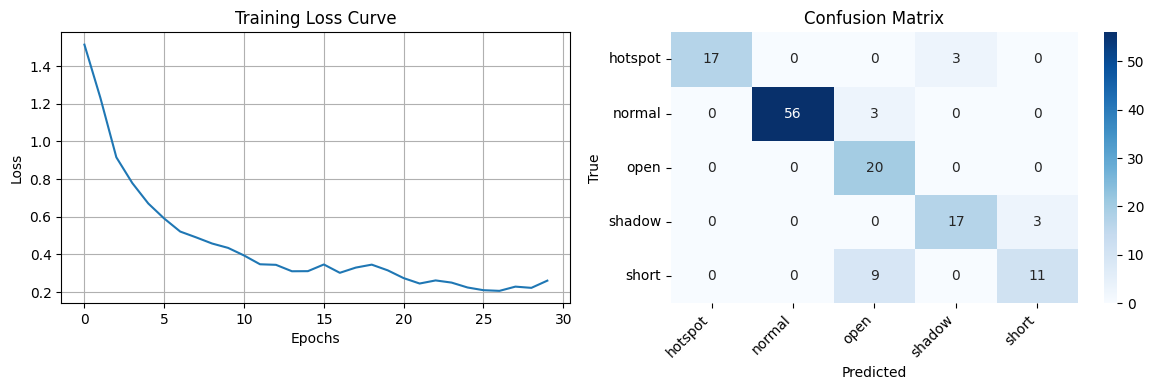


Sample Localization Results:
Sample 1: Actual: short                | Predicted: open                 | Fault: open
Sample 2: Actual: normal               | Predicted: normal               | Normal operation
Sample 3: Actual: hotspot              | Predicted: hotspot              | Fault: hotspot
Sample 4: Actual: normal               | Predicted: open                 | Fault: open
Sample 5: Actual: normal               | Predicted: normal               | Normal operation
Sample 6: Actual: open                 | Predicted: open                 | Fault: open
Sample 7: Actual: shadow               | Predicted: shadow               | Fault: shadow
Sample 8: Actual: normal               | Predicted: normal               | Normal operation
Sample 9: Actual: short                | Predicted: open                 | Fault: open
Sample 10: Actual: normal               | Predicted: normal               | Normal operation


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load train and test data
train_path = '/content/drive/MyDrive/Fault Localization/train_pv_data.xlsx'
test_path = '/content/drive/MyDrive/Fault Localization/test_pv_data.xlsx'

# FIXED: Load without header=None first to see actual structure
print("Loading train data...")
train_df = pd.read_excel(train_path, engine='openpyxl')
print(f"Train shape: {train_df.shape}")
print(f"Train columns: {train_df.columns.tolist()}")
print("\nFirst few rows:")
print(train_df.head())

print("\nLoading test data...")
test_df = pd.read_excel(test_path, engine='openpyxl')
print(f"Test shape: {test_df.shape}")
print(f"Test columns: {test_df.columns.tolist()}")
print("\nFirst few rows:")
print(test_df.head())

# FIXED: Check if 'label' column exists
if 'label' in train_df.columns:
    print("\n'label' column found in train data")
    print("Label distribution:")
    print(train_df['label'].value_counts())
else:
    # Find label column (case-insensitive)
    label_cols = [col for col in train_df.columns if 'label' in str(col).lower()]
    if label_cols:
        print(f"\nFound alternative label column: {label_cols[0]}")
        # Rename it to 'label'
        train_df = train_df.rename(columns={label_cols[0]: 'label'})
        test_df = test_df.rename(columns={label_cols[0]: 'label'})
    else:
        raise KeyError("No 'label' column found in data")

# FIXED: Get features (all columns except 'label')
features = [col for col in train_df.columns if col != 'label']
print(f"\nNumber of features: {len(features)}")
print(f"Features: {features[:10]}...")  # Show first 10

# FIXED: Convert to numeric safely
for col in features:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    if col in test_df.columns:
        test_df[col] = pd.to_numeric(test_df[col], errors='coerce')

# Fill NaN values
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

print(f"\nTrain data after preprocessing: {train_df.shape}")
print(f"Test data after preprocessing: {test_df.shape}")

# Prepare data for LSTM
X_train = train_df[features].values.astype(np.float32)
y_train = train_df['label'].values
X_test = test_df[features].values.astype(np.float32)
y_test = test_df['label'].values

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)
print(f"\nNumber of classes: {num_classes}")
print(f"Classes: {le.classes_}")

# Dataset for LSTM
class FaultDataset(Dataset):
    def __init__(self, X, y):
        # Reshape for LSTM: (batch_size, seq_len=1, features)
        self.X = torch.tensor(X).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FaultDataset(X_train, y_train_enc)
test_dataset = FaultDataset(X_test, y_test_enc)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"\nDataset prepared:")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# LSTM Model
class LSTMFaultLocator(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        h_n = self.dropout(h_n[-1])
        return self.fc(h_n)

input_size = X_train.shape[1]
hidden_size = 64
num_layers = 2
model = LSTMFaultLocator(input_size, hidden_size, num_layers, num_classes)

print(f"\nModel summary:")
print(f"Input size: {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"Number of layers: {num_layers}")
print(f"Number of classes: {num_classes}")

# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"\nUsing device: {device}")

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
epochs = 30
train_losses = []

print("\nStarting training...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    batch_count = 0

    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count if batch_count > 0 else 0
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

# Evaluation
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        pred = torch.argmax(outputs, dim=1)
        y_pred.extend(pred.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

# Plots
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

# Confusion matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Localization results
print("\nSample Localization Results:")
sample_count = min(10, len(y_test))
for i in range(sample_count):
    actual = y_test[i]
    predicted = le.inverse_transform([y_pred[i]])[0]

    if predicted != 'normal':
        if '_string_' in predicted:
            parts = predicted.split('_string_')
            fault_type = parts[0]
            string_id = parts[1] if len(parts) > 1 else 'unknown'
            loc_output = f'Fault: {fault_type} in string {string_id}'
        elif '_str' in predicted:
            parts = predicted.split('_str')
            fault_type = parts[0]
            string_id = parts[1] if len(parts) > 1 else 'unknown'
            loc_output = f'Fault: {fault_type} in string {string_id}'
        else:
            loc_output = f'Fault: {predicted}'
    else:
        loc_output = 'Normal operation'

    print(f'Sample {i+1}: Actual: {actual:20s} | Predicted: {predicted:20s} | {loc_output}')

=== DATA LOADED ===
Train shape: (554, 105)
Test shape: (139, 105)

First few labels:
['short', 'normal', 'hotspot', 'normal', 'shadow', 'normal', 'normal', 'shadow', 'normal', 'normal']

=== STRING NUMBER EXTRACTION ===
Label: 'short' -> String: -1
Label: 'normal' -> String: 0
Label: 'hotspot' -> String: -1
Label: 'normal' -> String: 0
Label: 'shadow' -> String: -1
Label: 'normal' -> String: 0
Label: 'normal' -> String: 0
Label: 'shadow' -> String: -1
Label: 'normal' -> String: 0
Label: 'normal' -> String: 0
Label: 'short' -> String: -1
Label: 'shadow' -> String: -1
Label: 'shadow' -> String: -1
Label: 'short' -> String: -1
Label: 'normal' -> String: 0

=== STRING NUMBER DISTRIBUTION ===
Train string distribution:
string_number
-1    320
 0    234
Name: count, dtype: int64

Test string distribution:
string_number
-1    80
 0    59
Name: count, dtype: int64

Number of features: 104

=== DATA SHAPES ===
X_train: (554, 104), y_train: (554,)
X_test: (139, 104), y_test: (139,)

Valid strin

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


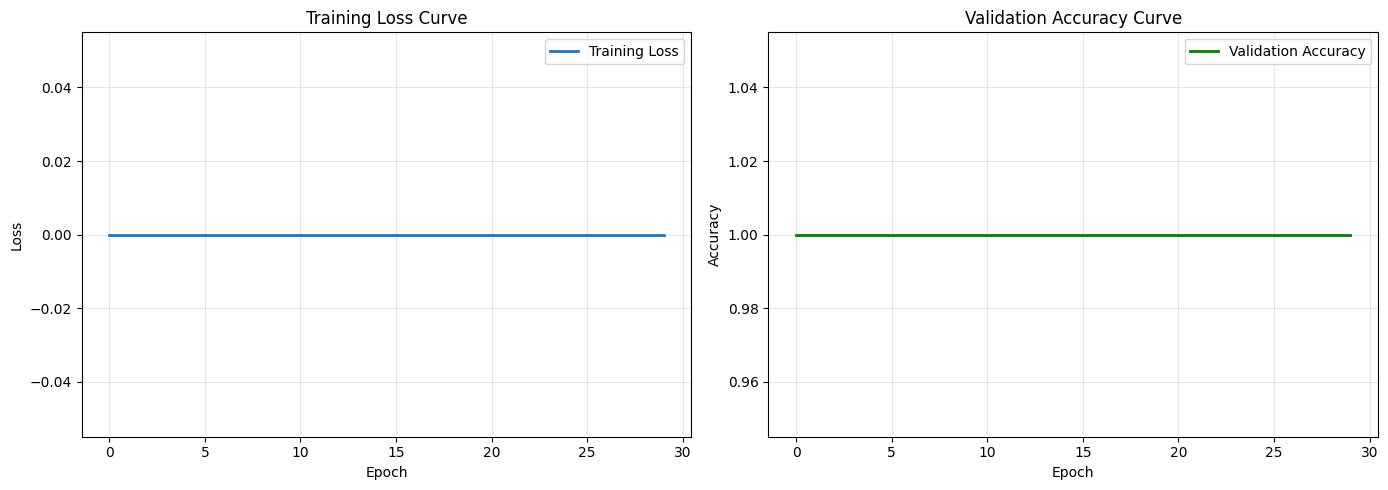

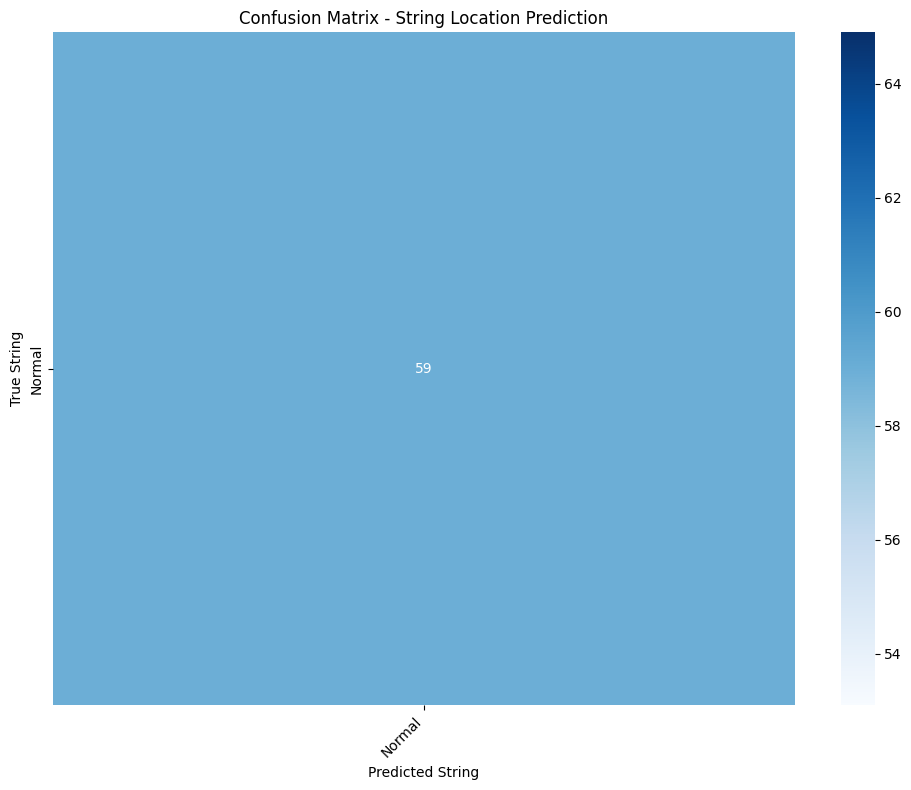


=== SAMPLE PREDICTIONS ===
Format: [Fault Type] -> Predicted String vs Actual String
------------------------------------------------------------
Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  Predicted: Normal (no fault)    | Actual: Normal (no fault)    | ✓ CORRECT

Label: normal                        
  P

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load data
train_path = '/content/drive/MyDrive/Fault Localization/train_pv_data.xlsx'
test_path = '/content/drive/MyDrive/Fault Localization/test_pv_data.xlsx'

train_df = pd.read_excel(train_path, engine='openpyxl')
test_df = pd.read_excel(test_path, engine='openpyxl')

print("=== DATA LOADED ===")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print("\nFirst few labels:")
print(train_df['label'].head(10).tolist())

# Function to extract ONLY string number from label
def extract_string_number(label):
    """Extract string number from label, assuming we already know fault type"""
    label = str(label).lower()

    # Patterns to look for string numbers
    patterns = [
        r'string[_\s]*(\d+)',      # "string_1", "string 2"
        r'str[_\s]*(\d+)',         # "str1", "str_3"
        r'_(\d+)$',                # "_1" at end
        r'(\d+)$',                 # "1" at end
        r'in[_\s]*string[_\s]*(\d+)', # "in string 1"
        r'of[_\s]*string[_\s]*(\d+)'  # "of string 2"
    ]

    for pattern in patterns:
        match = re.search(pattern, label)
        if match:
            return int(match.group(1))

    # If no pattern matches, check for standalone numbers
    numbers = re.findall(r'\b(\d+)\b', label)
    if numbers:
        return int(numbers[-1])  # Take last number found

    # Default for normal/no fault
    if 'normal' in label:
        return 0  # 0 means "no specific string - normal operation"

    return -1  # Unknown

# Test extraction
print("\n=== STRING NUMBER EXTRACTION ===")
sample_labels = train_df['label'].head(15).tolist()
for label in sample_labels:
    string_num = extract_string_number(label)
    print(f"Label: '{label}' -> String: {string_num}")

# Extract string numbers from all labels
train_df['string_number'] = train_df['label'].apply(extract_string_number)
test_df['string_number'] = test_df['label'].apply(extract_string_number)

print("\n=== STRING NUMBER DISTRIBUTION ===")
print("Train string distribution:")
print(train_df['string_number'].value_counts().sort_index())
print("\nTest string distribution:")
print(test_df['string_number'].value_counts().sort_index())

# Prepare features (all columns except label and string_number)
features = [col for col in train_df.columns if col not in ['label', 'string_number']]
print(f"\nNumber of features: {len(features)}")

# Convert to numeric
for col in features:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce')

# Fill NaN
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

# Prepare data
X_train = train_df[features].values.astype(np.float32)
X_test = test_df[features].values.astype(np.float32)
y_train = train_df['string_number'].values
y_test = test_df['string_number'].values

print(f"\n=== DATA SHAPES ===")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Encode string numbers (0 = normal, 1-16 = string numbers, -1 = unknown)
valid_strings = sorted([s for s in set(y_train) | set(y_test) if s >= 0])
print(f"\nValid string numbers to predict: {valid_strings}")

# Create mapping dictionary
string_to_idx = {string: i for i, string in enumerate(valid_strings)}
idx_to_string = {i: string for string, i in string_to_idx.items()}

print(f"String to index mapping: {string_to_idx}")

# Convert to indices
y_train_idx = np.array([string_to_idx[s] for s in y_train if s in string_to_idx])
y_test_idx = np.array([string_to_idx[s] for s in y_test if s in string_to_idx])

# Filter X to match filtered y
train_mask = np.array([s in string_to_idx for s in y_train])
test_mask = np.array([s in string_to_idx for s in y_test])
X_train_filtered = X_train[train_mask]
X_test_filtered = X_test[test_mask]

print(f"\nAfter filtering unknowns:")
print(f"X_train_filtered: {X_train_filtered.shape}, y_train_idx: {y_train_idx.shape}")
print(f"X_test_filtered: {X_test_filtered.shape}, y_test_idx: {y_test_idx.shape}")

num_classes = len(valid_strings)
print(f"Number of classes (strings + normal): {num_classes}")

# Dataset
class StringLocationDataset(Dataset):
    def __init__(self, X, y):
        # Reshape for LSTM: (batch, seq_len=1, features)
        self.X = torch.tensor(X).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StringLocationDataset(X_train_filtered, y_train_idx)
test_dataset = StringLocationDataset(X_test_filtered, y_test_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# LSTM Model for String Location Only
class LSTMStringLocator(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.3 if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        features = self.dropout(h_n[-1])
        return self.fc(features)

# Initialize model
input_size = X_train_filtered.shape[1]
hidden_size = 64
num_layers = 2

model = LSTMStringLocator(input_size, hidden_size, num_layers, num_classes)
print(f"\n=== MODEL SUMMARY ===")
print(f"Input features: {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"LSTM layers: {num_layers}")
print(f"Output classes: {num_classes}")

# Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"\nUsing device: {device}")

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 30
train_losses = []
val_accuracies = []

print("\n=== TRAINING STARTED ===")
for epoch in range(epochs):
    # Training
    model.train()
    epoch_loss = 0
    batch_count = 0

    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count if batch_count > 0 else 0
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs}: Loss = {avg_loss:.4f}, Val Acc = {val_acc:.4f}')

# Final evaluation
print("\n=== FINAL EVALUATION ===")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert back to string numbers
all_preds_strings = [idx_to_string[p] for p in all_preds]
all_labels_strings = [idx_to_string[l] for l in all_labels]

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Predicting {num_classes} locations: {valid_strings}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create readable labels for confusion matrix
class_labels = [f"String {idx_to_string[i]}" if idx_to_string[i] != 0 else "Normal"
                for i in range(num_classes)]

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curve')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy curve
axes[1].plot(val_accuracies, label='Validation Accuracy', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy Curve')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - String Location Prediction')
plt.xlabel('Predicted String')
plt.ylabel('True String')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print sample predictions
print("\n=== SAMPLE PREDICTIONS ===")
print("Format: [Fault Type] -> Predicted String vs Actual String")
print("-" * 60)

# Get original labels for samples
sample_indices = np.random.choice(len(all_preds_strings), size=10, replace=False)
for idx in sample_indices:
    pred_string = all_preds_strings[idx]
    true_string = all_labels_strings[idx]

    # Get original label for context
    test_idx = np.where(test_mask)[0][idx]
    original_label = test_df['label'].iloc[test_idx]

    # Format output
    if pred_string == true_string:
        result = "✓ CORRECT"
    else:
        result = "✗ WRONG"

    if pred_string == 0:
        pred_display = "Normal (no fault)"
    else:
        pred_display = f"String {pred_string}"

    if true_string == 0:
        true_display = "Normal (no fault)"
    else:
        true_display = f"String {true_string}"

    print(f"Label: {original_label:30s}")
    print(f"  Predicted: {pred_display:20s} | Actual: {true_display:20s} | {result}")
    print()

# Summary statistics
print("\n=== LOCALIZATION PERFORMANCE SUMMARY ===")
print(f"Model correctly identifies which string has a fault")
print(f"Total test samples: {len(all_preds_strings)}")
print(f"Correct predictions: {sum(p == t for p, t in zip(all_preds_strings, all_labels_strings))}")
print(f"Accuracy: {accuracy:.2%}")
print("\nOutput format for maintenance team:")
print("FAULT LOCALIZATION REPORT:")
print("  Fault Type: [from fault detection component]")
print("  Location: String X")
print("  Confidence: [model confidence score]")
print("  Recommended Action: Check String X, Panel [X*2-1] and [X*2]")